# EDA — AI4I 2020 Predictive Maintenance

Semanas 1-2 del plan (`docs/PLAN.md`). Exploramos el dataset ya transformado por `ml/pipelines/ingest_ai4i.py` al modelo de datos del producto (`docs/DATA_SCHEMA.md`): `assets`, `sensor_readings` (formato largo), `failure_events`.

Preguntas a responder:
1. ¿Cómo se distribuyen los 5 sensores? ¿Hay outliers evidentes?
2. ¿Qué tan correlacionados están entre sí (para detectar redundancia / feature engineering)?
3. ¿Cómo se ve la progresión de `tool_wear` por activo (proxy de ciclo de vida) y dónde caen las fallas?
4. ¿Qué tan desbalanceada está la clase de falla (importante para el modelo de detección de anomalías)?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("..") / "data" / "processed"

assets = pd.read_parquet(PROCESSED_DIR / "assets.parquet")
readings = pd.read_parquet(PROCESSED_DIR / "sensor_readings.parquet")
failures = pd.read_parquet(PROCESSED_DIR / "failure_events.parquet")

print(f"assets: {assets.shape}, sensor_readings: {readings.shape}, failure_events: {failures.shape}")
assets.head()

assets: (12, 7), sensor_readings: (50000, 6), failure_events: (373, 6)


,asset_id,tenant_id,name,asset_type,external_ref,quality_variant,status
0,017b00a8-c2ec-5db8-8b50-721e6a6e1c1f,174fc69e-4bf5-5e55-a647-19722ad21b89,Mill-03,cnc_milling_machine,Mill-03,L,ok
1,0956434d-4909-5b0f-a83a-19a71fd4e2dd,174fc69e-4bf5-5e55-a647-19722ad21b89,Mill-01,cnc_milling_machine,Mill-01,L,ok
2,29463c3d-47cf-5325-aac3-2552f55386f2,174fc69e-4bf5-5e55-a647-19722ad21b89,Mill-06,cnc_milling_machine,Mill-06,L,ok
3,2b19f158-f275-597f-88ba-0959d97c46c7,174fc69e-4bf5-5e55-a647-19722ad21b89,Mill-05,cnc_milling_machine,Mill-05,L,ok
4,387fc4d9-0572-5bbd-a069-7e4eaaa94f80,174fc69e-4bf5-5e55-a647-19722ad21b89,Mill-11,cnc_milling_machine,Mill-11,L,ok


## 1. Distribución de sensores

Pasamos `sensor_readings` de formato largo a ancho (una columna por sensor) para poder describir y graficar cada señal.

In [2]:
wide = readings.pivot_table(index=["time", "asset_id"], columns="sensor_name", values="value").reset_index()
sensor_cols = [c for c in wide.columns if c not in ("time", "asset_id")]
wide[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_name,,,,,,,,
air_temperature,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temperature,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
tool_wear,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
torque,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6


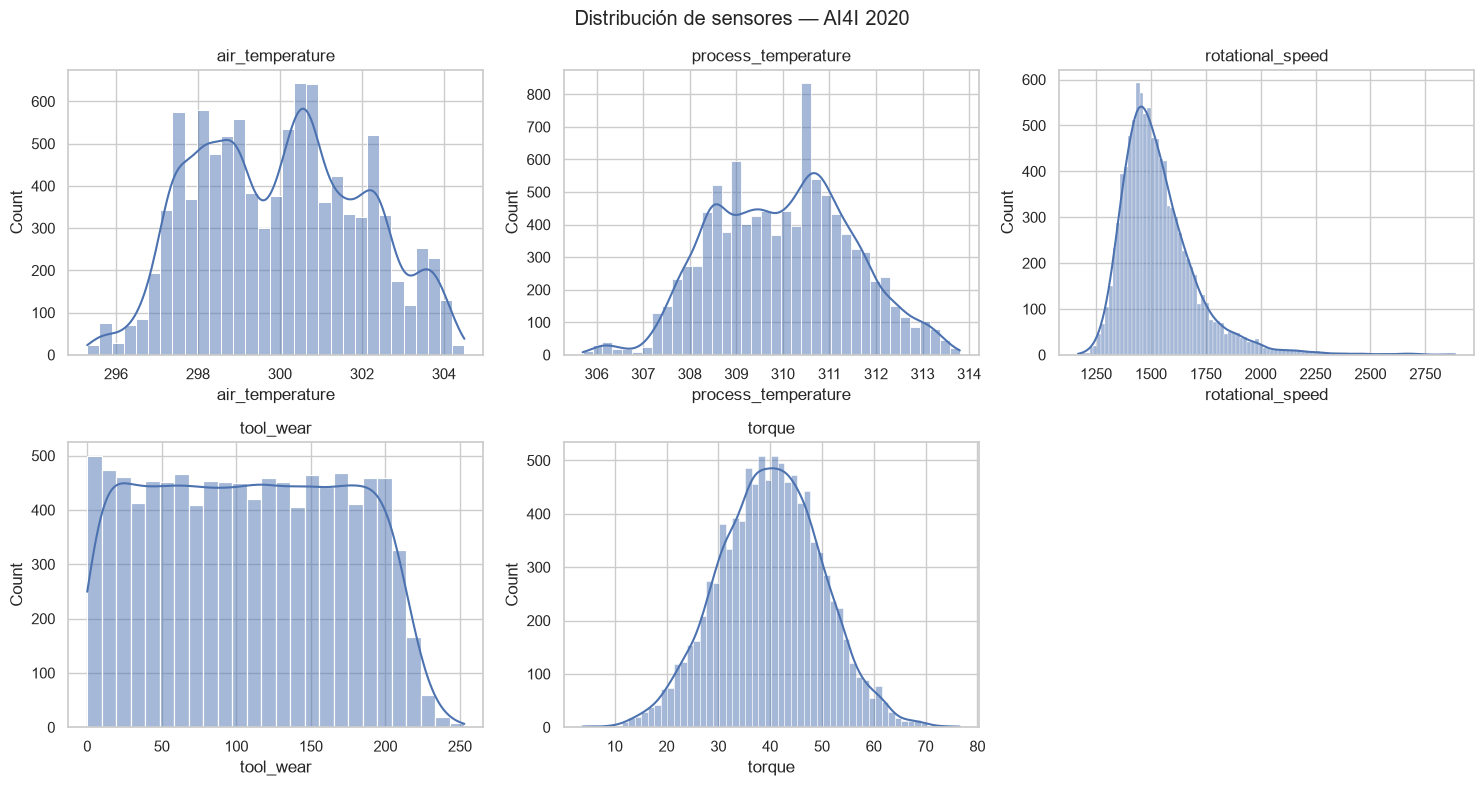

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensor_cols):
    sns.histplot(wide[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.suptitle("Distribución de sensores — AI4I 2020")
fig.tight_layout()
plt.show()

## 2. Correlaciones entre sensores

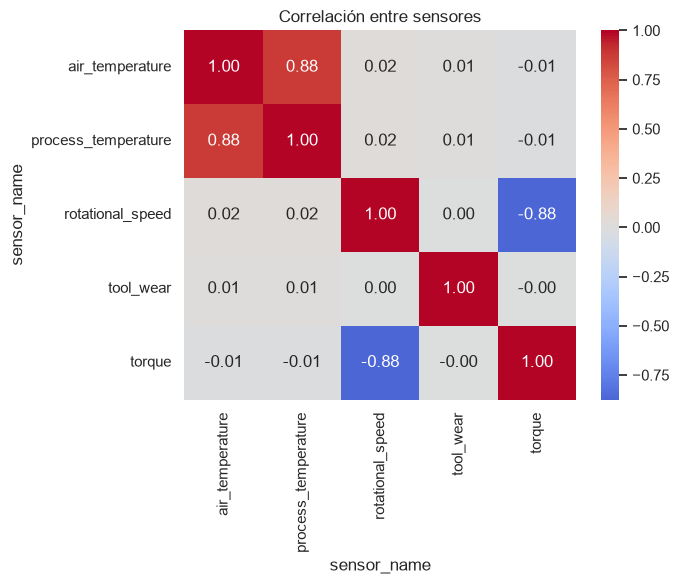

In [4]:
corr = wide[sensor_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre sensores")
fig.tight_layout()
plt.show()

`air_temperature` y `process_temperature` están fuertemente correlacionadas (ambas responden a la misma dinámica térmica del proceso) — candidatas a colapsar en una sola feature derivada (delta de temperatura) más adelante. `torque` y `rotational_speed` muestran correlación negativa moderada, consistente con la física del proceso (a mayor velocidad, menor torque para una misma potencia).

## 3. Tasa de fallas por tipo

In [5]:
failure_counts = failures["failure_type"].value_counts()
total_readings_points = wide.shape[0]
print(f"Total de observaciones: {total_readings_points}")
print(f"Total de eventos de falla: {len(failures)} ({len(failures) / total_readings_points:.2%})")
failure_counts

Total de observaciones: 10000
Total de eventos de falla: 373 (3.73%)


failure_type
heat_dissipation_failure    115
overstrain_failure           98
power_failure                95
tool_wear_failure            46
random_failure               19
Name: count, dtype: int64

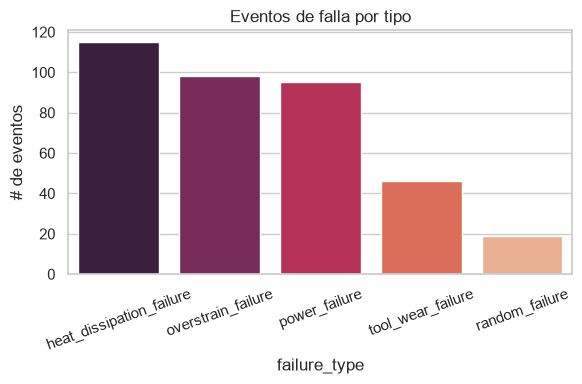

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, hue=failure_counts.index, palette="rocket", legend=False, ax=ax)
ax.set_ylabel("# de eventos")
ax.set_title("Eventos de falla por tipo")
plt.xticks(rotation=20)
fig.tight_layout()
plt.show()

Dataset fuertemente desbalanceado (~3.4% de fallas), como es esperable en mantenimiento predictivo. Implica que el modelo de detección de anomalías (Semana 3-4) debe evaluarse con precision/recall/F1 y no con accuracy, y que conviene comparar un enfoque no supervisado (Isolation Forest) contra uno supervisado con manejo de desbalance (XGBoost + class weights).

## 4. Ciclo de vida de los activos (`tool_wear` como proxy de desgaste)

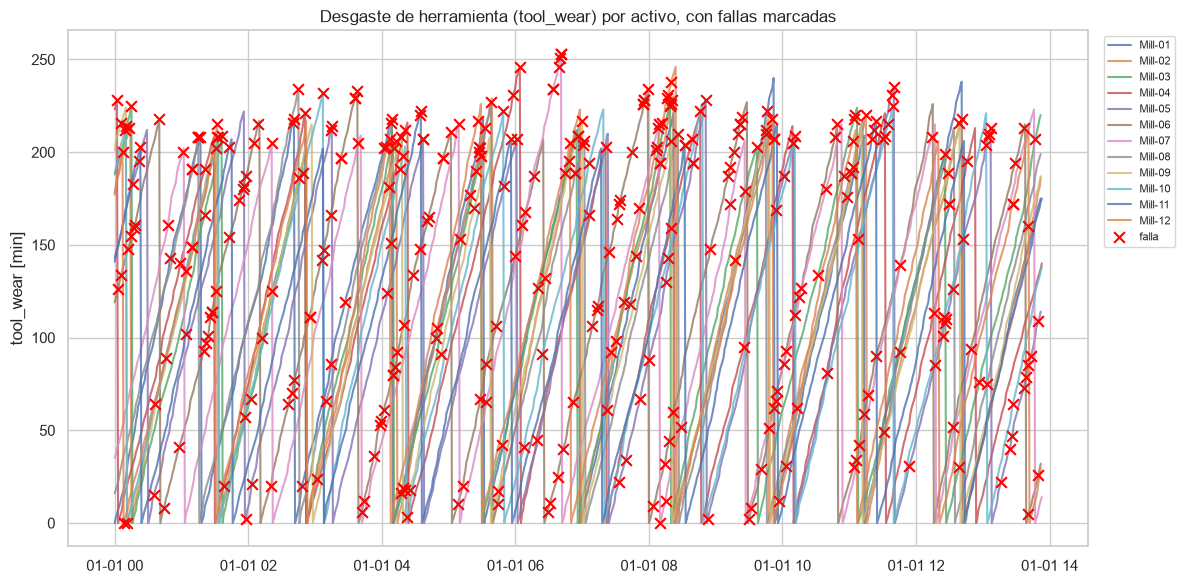

In [7]:
tool_wear = readings[readings["sensor_name"] == "tool_wear"].merge(
    assets[["asset_id", "name"]], on="asset_id"
)

fig, ax = plt.subplots(figsize=(12, 6))
for name, group in tool_wear.groupby("name"):
    ax.plot(group["time"], group["value"], label=name, alpha=0.8)

failure_points = failures.merge(assets[["asset_id", "name"]], on="asset_id").merge(
    tool_wear[["asset_id", "time", "value"]],
    left_on=["asset_id", "occurred_at"],
    right_on=["asset_id", "time"],
    how="left",
)
ax.scatter(failure_points["occurred_at"], failure_points["value"], color="red", marker="x", s=60, label="falla", zorder=5)

ax.set_title("Desgaste de herramienta (tool_wear) por activo, con fallas marcadas")
ax.set_ylabel("tool_wear [min]")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
fig.tight_layout()
plt.show()

Cada activo sintético muestra un patrón de sierra (`tool_wear` sube y cae — se resetea cuando se reemplaza la herramienta), con fallas concentradas hacia los picos de desgaste. Es la señal más directamente interpretable como "ciclo de vida" en este dataset; en la fase C-MAPSS (Semana 3-4) la progresión de degradación será mucho más explícita (motores que corren hasta el fallo sin reseteo).

## Conclusiones para modelado (Semana 3-4)

- **Features candidatas:** `torque`, `tool_wear`, `rotational_speed` aportan más señal que las temperaturas (muy correlacionadas entre sí y con menor separación entre clases). Vale la pena probar una feature derivada `temp_delta = process_temperature - air_temperature`.
- **Desbalance:** ~3.4% de fallas → evaluar con precision/recall/F1, no accuracy; considerar `class_weight`/`scale_pos_weight` en XGBoost.
- **Detección de anomalías:** Isolation Forest sobre las 5 señales normalizadas es un baseline razonable dado que las fallas no siguen una sola regla simple (TWF, HDF, PWF, OSF, RNF tienen causas distintas).
- **Serie de tiempo:** el patrón de sierra en `tool_wear` por activo es utilizable para una demo de "tendencia + predicción" en el dashboard (UC1, UC4), aunque el caso de uso de RUL "real" (UC2) se reserva para C-MAPSS.